In [1]:
# Import necessary packages

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm import tqdm, trange
import sctop as top # note: this uses sctop version 1.0.0
from itertools import combinations
from scipy.special import softmax
import matplotlib as mpl

# Settings for making nice plots

sns.set(context='talk', color_codes=True, palette='deep', style='whitegrid', font_scale=1.2,
        rc={'mathtext.fontset': 'cm', 'xtick.direction': 'in','ytick.direction': 'in',
            'figure.dpi':100, 'text.usetex':False}) #'axes.linewidth': 1.5

In [2]:
# Define potentials, their gradients, and the approximate positions of their attractors

def triple_cusp_pot(x, y, params):
    V = x**6 - x**4 + x**2 + 2*(x**2)*y + 4*y**4 - y**2 + params['f']*x + params['k']*y
    return V

def triple_cusp_grad(x, y, params):
    grad_x = 6*x**5 - 4*x**3 + 2*x + 4*x*y + params['f']
    grad_y = 16*y**3 - 2*y + 2*x**2 + params['k']    
    return grad_x, grad_y

def het_flip_pot(x, y, params):
    V = x**4 + 2*(x**2)*y + y**4 - y**3 - y**2 + params['f']*x + params['k']*y
    return V

def het_flip_grad(x, y, params):
    grad_x = 4*x**3 + 4*x*y + params['f'] 
    grad_y = 4*y**3 - 3*y**2 + 2*x**2 - 2*y + params['k'] 
    return grad_x, grad_y

def double_cusp_pot(x, y, params):
    V = x**4 + 4*(x**2)*y + y**4 - y**3 + y**2 + params['f']*x + params['k']*y
    return V

def double_cusp_grad(x, y, params):
    grad_x = 4*x**3 + 8*x*y + params['f']
    grad_y = 4*y**3 - 3*y**2 + 4*x**2 + 2*y - params['k']
    return grad_x, grad_y

triple_cusp_coords = {'y0': 0.345, 
                     'x1': 0.838,
                     'y1': -0.537
                    }

# heteroclinic flip:
het_flip_coords = {'y0': 0.82,
                    'x1': 0.964,
                    'y1': -0.877
                   }

# double cusp:
double_cusp_coords = {'y0': 0.085,
                      'x1': 1.349,
                      'y1': -0.911
                      }

In [213]:
# Helper utilities: compute Hessian and trace unstable manifolds (unstable eigenvectors of Hessian)
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve

def compute_hessian(x0, y0, grad_func, params, h=1e-5):
    """Numerical Hessian of V using central differences on the gradient.

    grad_func(x,y,params) -> (dV/dx, dV/dy)
    Returns 2x2 Hessian matrix H where H[i,j] = d^2 V / (d var_i d var_j)
    """
    g_x_plus = grad_func(x0 + h, y0, params)
    g_x_minus = grad_func(x0 - h, y0, params)
    g_y_plus = grad_func(x0, y0 + h, params)
    g_y_minus = grad_func(x0, y0 - h, params)

    d2V_dx2 = (g_x_plus[0] - g_x_minus[0]) / (2*h)
    d2V_dy2 = (g_y_plus[1] - g_y_minus[1]) / (2*h)
    d2V_dxdy = (g_y_plus[0] - g_y_minus[0]) / (2*h)
    d2V_dydx = (g_x_plus[1] - g_x_minus[1]) / (2*h)

    H = np.array([[d2V_dx2, d2V_dxdy], [d2V_dydx, d2V_dy2]])
    return H


def integrate_forward(x0, y0, grad_func, params, bounds, t_max=50, n_steps=2000):
    """Integrate dx/dt = -grad V starting from (x0,y0) forward in time.

    Stops sampling once solution leaves `bounds` (xmin,xmax,ymin,ymax).
    Returns (xs, ys) arrays (trimmed to bounds).
    """
    def vf(t, z):
        gx, gy = grad_func(z[0], z[1], params)
        return [-gx, -gy]

    t_eval = np.linspace(0, t_max, n_steps)
    sol = solve_ivp(vf, [0, t_max], [x0, y0], t_eval=t_eval, max_step=0.5)
    xs, ys = sol.y[0], sol.y[1]
    xmin, xmax, ymin, ymax = bounds
    mask = (xs >= xmin) & (xs <= xmax) & (ys >= ymin) & (ys <= ymax)
    if mask.sum() == 0:
        return np.array([]), np.array([])
    # keep initial contiguous block inside bounds
    valid_idx = np.where(mask)[0]
    last = valid_idx[-1]
    return xs[:last+1], ys[:last+1]


def unstable_manifold_trajectories(saddle, grad_func, params, bounds, eps=1e-3, t_max=50, n_steps=2000):
    """Return trajectories (list of (xs,ys)) tracing the unstable manifold from a saddle.

    We find Hessian eigenvectors with negative eigenvalue (these correspond to
    unstable directions for the gradient-descent flow dx/dt = -grad(V)). For
    each unstable eigenvector we integrate forward from saddle +/- eps*evec.
    """
    x0, y0 = saddle
    H = compute_hessian(x0, y0, grad_func, params)
    vals, vecs = np.linalg.eig(H)
    trajs = []
    for i, val in enumerate(vals):
        if val < 0:  # unstable direction for -grad flow
            evec = vecs[:, i]
            for s in [1.0, -1.0]:
                xi = x0 + s * eps * evec[0]
                yi = y0 + s * eps * evec[1]
                xs, ys = integrate_forward(xi, yi, grad_func, params, bounds, t_max=t_max, n_steps=n_steps)
                if xs.size:
                    trajs.append((xs, ys))
    return trajs

# Triple cusp potential

## Landscape plots

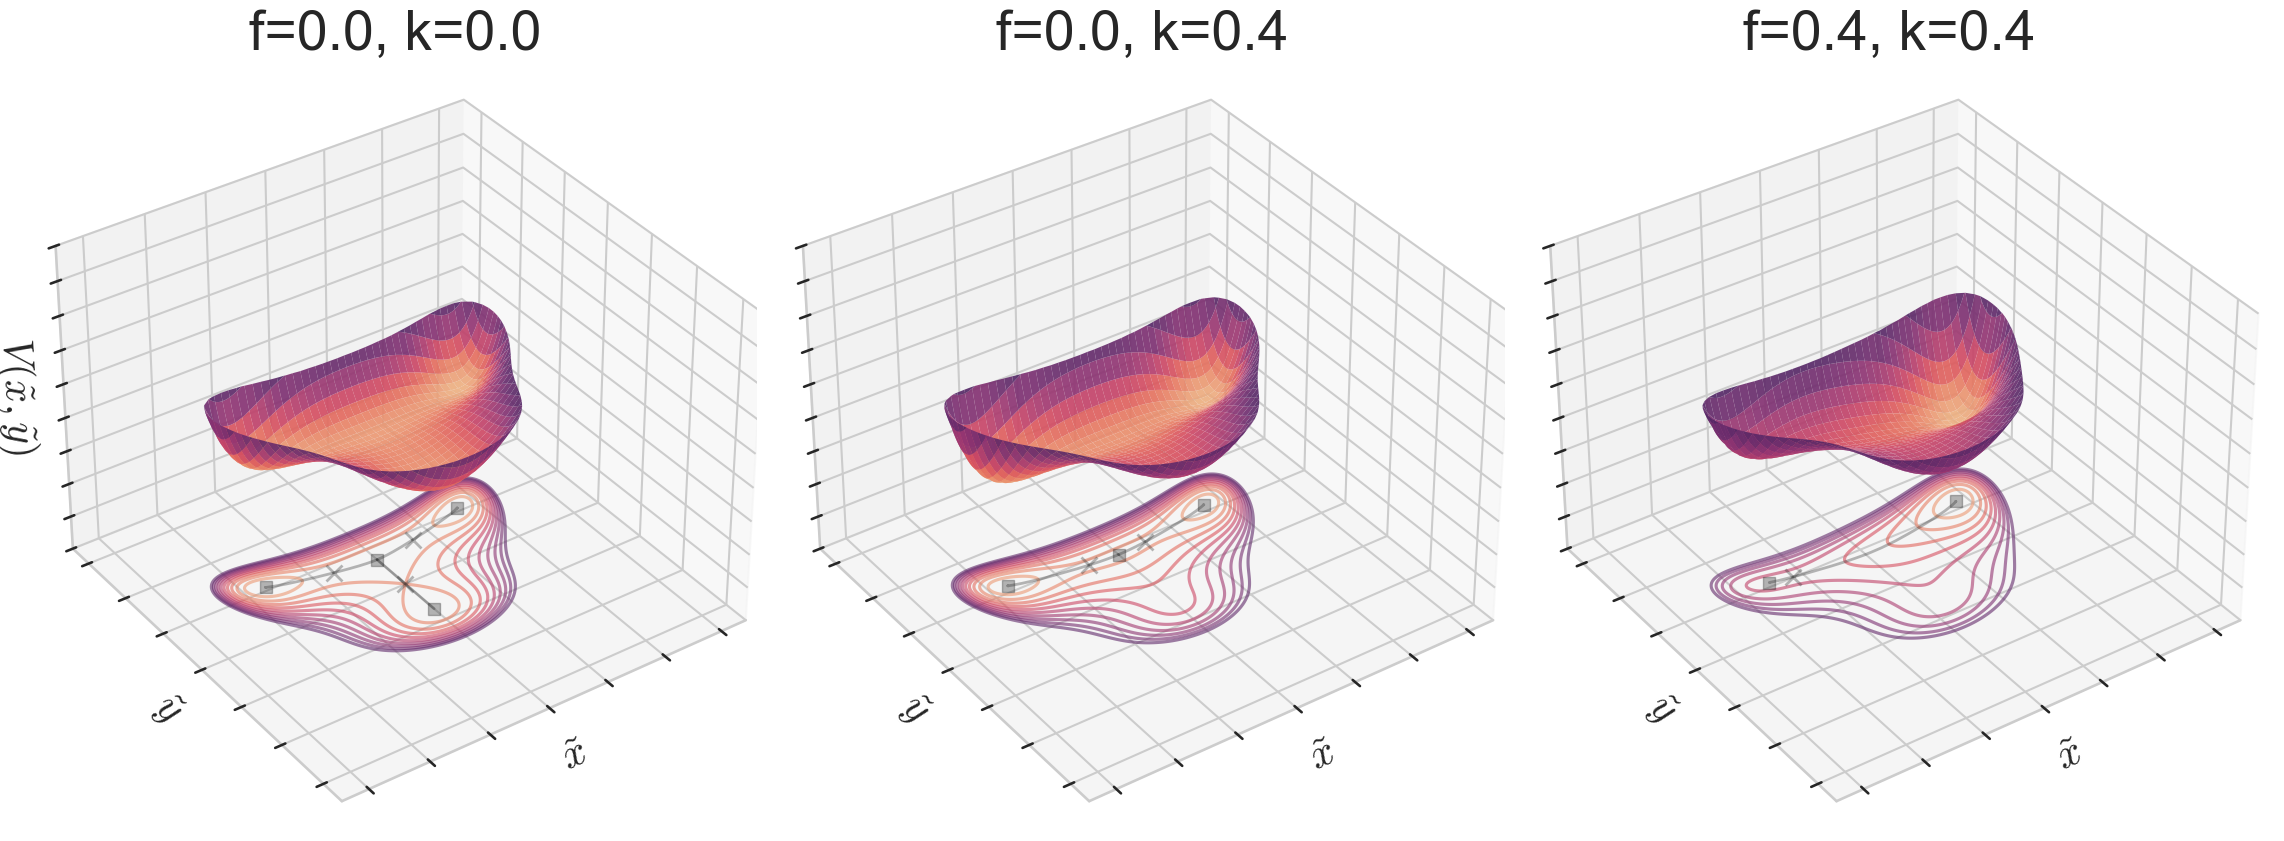

In [236]:
def plot_triple_cusp_3d_subplots():
    cases = [(0, 0), (0, 0.4), (0.4, 0.4)]
    fig = plt.figure(figsize=(30, 10))
    
    for idx, (f, k) in enumerate(cases):
        # ax.contour(X, Y, -DX, levels=[0], colors='gray', linewidths=2, linestyles='--')
        # ax.contour(X, Y, -DY, levels=[0], colors='gray', linewidths=2, linestyles='-')
        params = {'f': f, 'k': k}
        
        # Create a grid of x and y values
        nx = 5000
        x = np.linspace(-1.5, 1.5, nx)
        y = np.linspace(-1.5, 1.5, nx)
        X, Y = np.meshgrid(x, y)
        
        cap = 0.7
        
        # Compute potential
        Z = triple_cusp_pot(X, Y, params)
        Z = np.clip(Z, -1, cap)
        
        # Create subplot
        ax = fig.add_subplot(1, 3, idx + 1, projection='3d')
        
        # Plot surface with flare colormap
        cmap_flare = sns.color_palette('flare', as_cmap=True)
        Z_plot = Z.copy()
        Z_plot[Z_plot == cap] = np.nan
        surf = ax.plot_surface(X, Y, Z_plot, cmap=cmap_flare, alpha=0.9, edgecolor='none', antialiased=True)
        
        offset = -2
        
        # Add contour plot on the x-y plane
        contour = ax.contour(X, Y, Z, levels=10, cmap=cmap_flare, offset=offset, alpha=0.6)
        
        ax.set_zlim(-2, 2.5)
        
        # Larger axis labels, no tick labels
        ax.set_xlabel(r'$\tilde{x}$', fontsize=30)
        ax.set_ylabel(r'$\tilde{y}$', fontsize=30)
        
        if idx == 0:
            ax.set_zlabel(r'$V(\tilde{x}, \tilde{y})$', fontsize=30, labelpad=0)
            # try:
            #     ax.zaxis.set_label_coords(0.5, 0.5)
            # except Exception:
            #     pass
            ax.zaxis.label.set_clip_on(False)

        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.set_zticklabels([])
        
        ax.set_title(f'f={f:.1f}, k={k:.1f}', fontsize=40)
        
        # Find and classify critical points
        critical_points = []
        for x0 in np.linspace(-1.5, 1.5, 5):
            for y0 in np.linspace(-1.5, 1.5, 5):
                sol = fsolve(lambda pos: triple_cusp_grad(pos[0], pos[1], params), [x0, y0], full_output=True)
                if sol[2] == 1:
                    point = sol[0]
                    is_new = True
                    for existing_point in critical_points:
                        if np.linalg.norm(point - existing_point) < 0.1:
                            is_new = False
                            break
                    if is_new:
                        critical_points.append(point)
        
        attractors = []
        saddles = []
        
        for point in critical_points:
            x_pt, y_pt = point
            h = 1e-5
            d2V_dx2 = (triple_cusp_grad(x_pt + h, y_pt, params)[0] - triple_cusp_grad(x_pt - h, y_pt, params)[0]) / (2*h)
            d2V_dy2 = (triple_cusp_grad(x_pt, y_pt + h, params)[1] - triple_cusp_grad(x_pt, y_pt - h, params)[1]) / (2*h)
            
            if d2V_dx2 > 0 and d2V_dy2 > 0:
                attractors.append(point)
            else:
                saddles.append(point)
        
        # Mark critical points
        for attractor in attractors:
            ax.plot(attractor[0], attractor[1], offset, 'ks', alpha=0.3, markersize=8)
        
        for saddle in saddles:
            ax.plot(saddle[0], saddle[1], offset, 'kx', alpha=0.3, markersize=12, markeredgewidth=2)
            bounds = (-1.5, 1.5, -1.5, 1.5)
            for xs, ys in unstable_manifold_trajectories(saddle, triple_cusp_grad, params, bounds, eps=1e-3, t_max=50, n_steps=1000):
                ax.plot(xs, ys, offset * np.ones_like(xs), color='k', linewidth=2, alpha=0.3)
        
        ax.view_init(elev=35, azim=55)

    # shift the whole set of subplots slightly right so left labels are visible
    fig.subplots_adjust(wspace=-0.1)
    plt.savefig('./figs/triple cusp landscape.pdf', bbox_inches="tight", dpi=300)
    
    plt.show()

plot_triple_cusp_3d_subplots()

In [230]:
def plot_triple_cusp_3d_interactive(f, k):
    params = {'f': f, 'k': k}
    
    # Create a grid of x and y values
    nx = 500
    x = np.linspace(-1.5, 1.5, nx)
    y = np.linspace(-1.5, 1.5, nx)
    X, Y = np.meshgrid(x, y)
    
    cap = 0.7
    
    # Compute potential
    Z = triple_cusp_pot(X, Y, params)
    Z = np.clip(Z, -1, cap)
    
    # Create figure
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot surface with flare colormap
    cmap_flare = sns.color_palette('flare', as_cmap=True)
    Z_plot = Z.copy()
    Z_plot[Z_plot == cap] = np.nan
    surf = ax.plot_surface(X, Y, Z_plot, cmap=cmap_flare, alpha=0.9, edgecolor='none', antialiased=True)
    
    offset = -2
    
    # Add contour plot on the x-y plane
    contour = ax.contour(X, Y, Z, levels=10, cmap=cmap_flare, offset=offset, alpha=0.6)
    
    ax.set_zlim(-2, 2.5)
    
    # Axis labels
    ax.set_xlabel(r'$\tilde{x}$', fontsize=20)
    ax.set_ylabel(r'$\tilde{y}$', fontsize=20)
    ax.set_zlabel(r'$V(\tilde{x}, \tilde{y})$', fontsize=20)
    
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_zticklabels([])
    
    ax.set_title(f'Triple Cusp Potential (f={f:.1f}, k={k:.1f})', fontsize=24)
    
    # Find and classify critical points
    critical_points = []
    for x0 in np.linspace(-1.5, 1.5, 5):
        for y0 in np.linspace(-1.5, 1.5, 5):
            sol = fsolve(lambda pos: triple_cusp_grad(pos[0], pos[1], params), [x0, y0], full_output=True)
            if sol[2] == 1:
                point = sol[0]
                is_new = True
                for existing_point in critical_points:
                    if np.linalg.norm(point - existing_point) < 0.1:
                        is_new = False
                        break
                if is_new:
                    critical_points.append(point)
    
    attractors = []
    saddles = []
    
    for point in critical_points:
        x_pt, y_pt = point
        h = 1e-5
        d2V_dx2 = (triple_cusp_grad(x_pt + h, y_pt, params)[0] - triple_cusp_grad(x_pt - h, y_pt, params)[0]) / (2*h)
        d2V_dy2 = (triple_cusp_grad(x_pt, y_pt + h, params)[1] - triple_cusp_grad(x_pt, y_pt - h, params)[1]) / (2*h)
        
        if d2V_dx2 > 0 and d2V_dy2 > 0:
            attractors.append(point)
        else:
            saddles.append(point)
    
    # Mark critical points
    for attractor in attractors:
        ax.plot(attractor[0], attractor[1], offset, 'ks', alpha=0.3, markersize=8)
    
    for saddle in saddles:
        ax.plot(saddle[0], saddle[1], offset, 'kx', alpha=0.3, markersize=12, markeredgewidth=2)
        # unstable manifolds projected to the x-y plane at z = offset
        bounds = (-1.5, 1.5, -1.5, 1.5)
        for xs, ys in unstable_manifold_trajectories(saddle, triple_cusp_grad, params, bounds, eps=1e-3, t_max=50, n_steps=1000):
            ax.plot(xs, ys, offset * np.ones_like(xs), color='k', linewidth=2, alpha=0.3)
    
    ax.view_init(elev=35, azim=55)
    # plt.tight_layout()
    plt.show()

interact(plot_triple_cusp_3d_interactive,
         f=FloatSlider(min=-2, max=2, step=0.1, value=0),
         k=FloatSlider(min=-2, max=2, step=0.1, value=0))

interactive(children=(FloatSlider(value=0.0, description='f', max=2.0, min=-2.0), FloatSlider(value=0.0, descr…

<function __main__.plot_triple_cusp_3d_interactive(f, k)>

## Stream plots

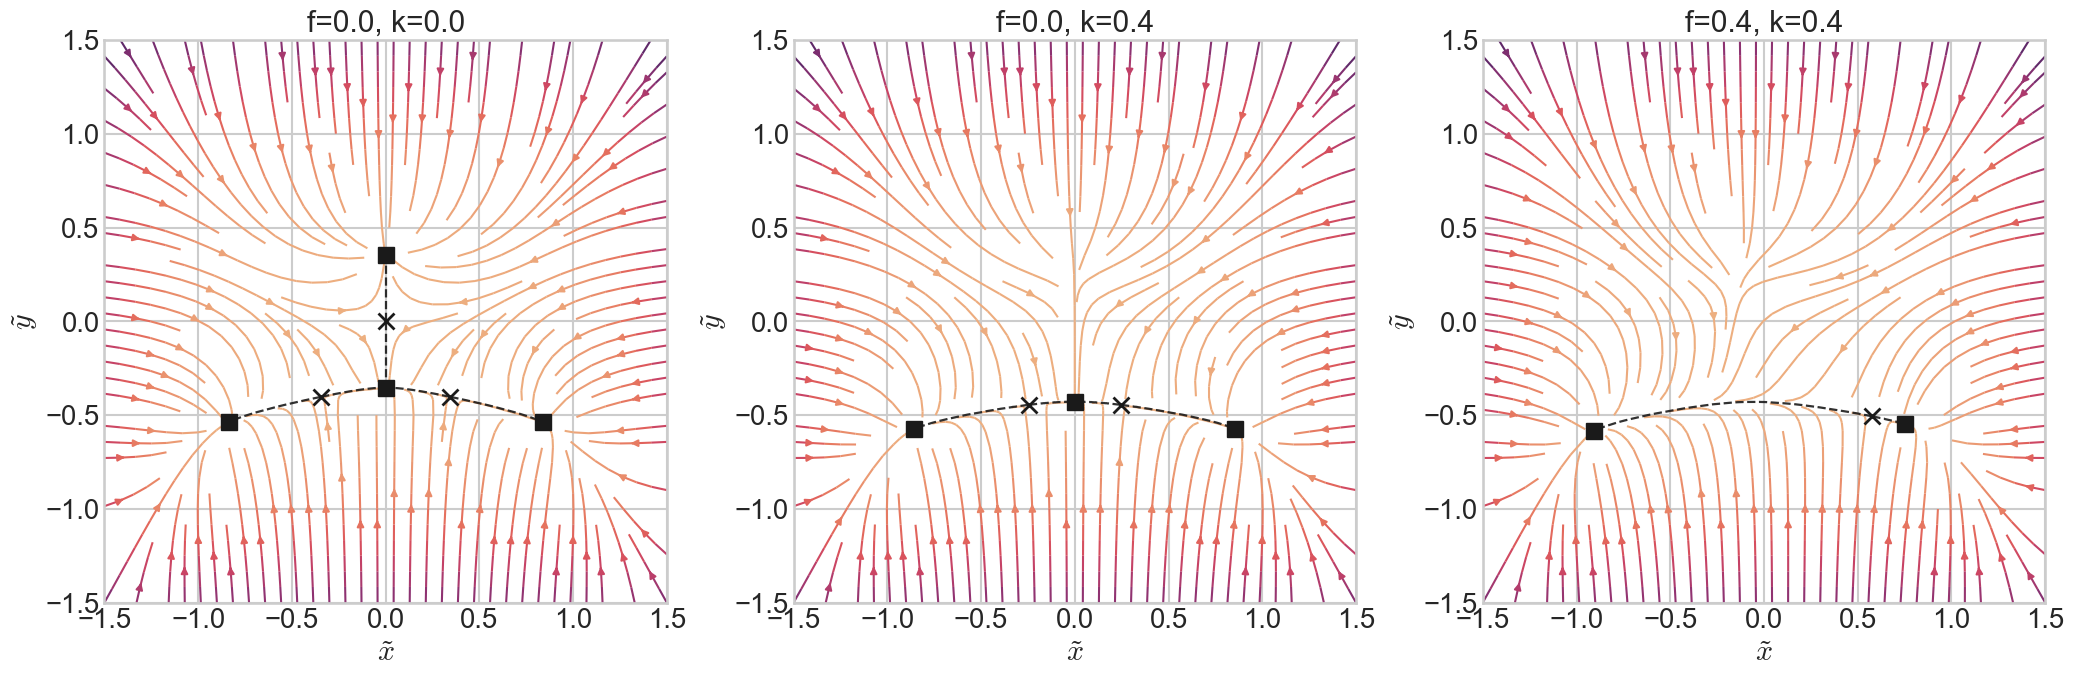

In [234]:
def plot_triple_cusp_streams_3d_subplots():
    cases = [(0, 0), (0, 0.4), (0.4, 0.4)]
    fig, axes = plt.subplots(1, 3, figsize=(21, 7))
    
    for idx, (f, k) in enumerate(cases):
        params = {'f': f, 'k': k}
        
        # Create a grid of x and y values
        nx = 1000
        x = np.linspace(-1.5, 1.5, nx)
        y = np.linspace(-1.5, 1.5, nx)
        X, Y = np.meshgrid(x, y)
        
        # Compute potential and gradient
        Z = triple_cusp_pot(X, Y, params)
        DX, DY = triple_cusp_grad(X, Y, params)
        
        # Find critical points (where both gradients are zero)
        critical_points = []
        for x0 in np.linspace(-1.5, 1.5, 5):
            for y0 in np.linspace(-1.5, 1.5, 5):
                sol = fsolve(lambda pos: triple_cusp_grad(pos[0], pos[1], params), [x0, y0], full_output=True)
                if sol[2] == 1:  # Solution converged
                    point = sol[0]
                    # Check if this point is not already in our list
                    is_new = True
                    for existing_point in critical_points:
                        if np.linalg.norm(point - existing_point) < 0.1:
                            is_new = False
                            break
                    if is_new:
                        critical_points.append(point)
        
        # Classify critical points using second derivatives
        attractors = []
        saddles = []
        
        for point in critical_points:
            x_pt, y_pt = point
            # Compute second derivatives numerically
            h = 1e-5
            d2V_dx2 = (triple_cusp_grad(x_pt + h, y_pt, params)[0] - triple_cusp_grad(x_pt - h, y_pt, params)[0]) / (2*h)
            d2V_dy2 = (triple_cusp_grad(x_pt, y_pt + h, params)[1] - triple_cusp_grad(x_pt, y_pt - h, params)[1]) / (2*h)
            
            if d2V_dx2 > 0 and d2V_dy2 > 0:
                attractors.append(point)
            else:
                saddles.append(point)
        
        # Speed for coloring
        speed = np.hypot(DX, DY)
        
        # Create streamplot
        ax = axes[idx]
        cmap_flare = sns.color_palette('flare', as_cmap=True)
        norm = mpl.colors.Normalize(vmin=0, vmax=np.nanmax(speed))
        
        strm = ax.streamplot(X, Y, -DX, -DY, color=speed, cmap=cmap_flare, norm=norm, 
                             density=1.2, linewidth=1.5, broken_streamlines=True)
        
        # Add nullclines
            # ax.contour(X, Y, -DX, levels=[0], colors='gray', linewidths=2, linestyles='--')
            # ax.contour(X, Y, -DY, levels=[0], colors='gray', linewidths=2, linestyles='-')
        
        # Mark attractors with black squares
        for attractor in attractors:
            ax.plot(attractor[0], attractor[1], 'ks', markersize=12, label='Attractor' if np.array_equal(attractor, attractors[0]) else '')
        
        # Mark saddle points with black X's
        for saddle in saddles:
            ax.plot(saddle[0], saddle[1], 'kx', markersize=12, markeredgewidth=2, label='Saddle' if np.array_equal(saddle, saddles[0]) else '')
            # restore nullclines instead of separatrices
            # ax.contour(X, Y, -DX, levels=[0], colors='gray', linewidths=2, linestyles='--')
            # ax.contour(X, Y, -DY, levels=[0], colors='gray', linewidths=2, linestyles='-')
            # add unstable manifolds
            bounds = (-1.5, 1.5, -1.5, 1.5)
            for xs, ys in unstable_manifold_trajectories(saddle, triple_cusp_grad, params, bounds, eps=1e-3, t_max=40, n_steps=800):
                ax.plot(xs, ys, color='k', linewidth=1.6, linestyle='--', alpha=0.9)
        
        ax.set_xlabel(r'$\tilde{x}$')
        ax.set_ylabel(r'$\tilde{y}$')
        ax.set_xlim(-1.5, 1.5)
        ax.set_ylim(-1.5, 1.5)
        ax.set_aspect('equal')
        ax.set_title(f'f={f:.1f}, k={k:.1f}')
        # ax.legend()
        
        # if idx == len(cases)-1:
        #   cbar = plt.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap_flare), ax=ax, label='Gradient magnitude')

    plt.tight_layout()
    
    plt.savefig("./figs/triple cusp streamplots.pdf", dpi=300, bbox_inches='tight')
    plt.show()

plot_triple_cusp_streams_3d_subplots()

In [221]:
def plot_triple_cusp_streams_attractors_saddles(f, k):
    params = {'f': f, 'k': k}
    
    # Create a grid of x and y values
    x = np.linspace(-1.5, 1.5, 300)
    y = np.linspace(-1.5, 1.5, 300)
    X, Y = np.meshgrid(x, y)
    
    # Compute potential and gradient
    Z = triple_cusp_pot(X, Y, params)
    DX, DY = triple_cusp_grad(X, Y, params)
    
    # Find critical points (where both gradients are zero)
    critical_points = []
    for x0 in np.linspace(-1.5, 1.5, 5):
        for y0 in np.linspace(-1.5, 1.5, 5):
            sol = fsolve(lambda pos: triple_cusp_grad(pos[0], pos[1], params), [x0, y0], full_output=True)
            if sol[2] == 1:  # Solution converged
                point = sol[0]
                # Check if this point is not already in our list
                is_new = True
                for existing_point in critical_points:
                    if np.linalg.norm(point - existing_point) < 0.1:
                        is_new = False
                        break
                if is_new:
                    critical_points.append(point)
    
    # Classify critical points using second derivatives
    attractors = []
    saddles = []
    
    for point in critical_points:
        x_pt, y_pt = point
        # Compute second derivatives numerically
        h = 1e-5
        d2V_dx2 = (triple_cusp_grad(x_pt + h, y_pt, params)[0] - triple_cusp_grad(x_pt - h, y_pt, params)[0]) / (2*h)
        d2V_dy2 = (triple_cusp_grad(x_pt, y_pt + h, params)[1] - triple_cusp_grad(x_pt, y_pt - h, params)[1]) / (2*h)
        
        if d2V_dx2 > 0 and d2V_dy2 > 0:
            attractors.append(point)
        else:
            saddles.append(point)
    
    # Speed for coloring
    speed = np.hypot(DX, DY)
    
    # Create streamplot
    fig, ax = plt.subplots(figsize=(8, 8))
    cmap_flare = sns.color_palette('flare', as_cmap=True)
    norm = mpl.colors.Normalize(vmin=0, vmax=np.nanmax(speed))
    
    strm = ax.streamplot(X, Y, -DX, -DY, color=speed, cmap=cmap_flare, norm=norm, 
                            density=1.2, linewidth=1.5, broken_streamlines=True)
    
    # ax.contour(X, Y, -DX, levels=[0], colors='gray', linewidths=2, linestyles='--')
    # ax.contour(X, Y, -DY, levels=[0], colors='gray', linewidths=2, linestyles='-')
    
    # Mark attractors with black squares
    for attractor in attractors:
        ax.plot(attractor[0], attractor[1], 'ks', markersize=12, label='Attractor' if np.array_equal(attractor, attractors[0]) else '')
    
    # Mark saddle points with black X's
    for saddle in saddles:
        ax.plot(saddle[0], saddle[1], 'kx', markersize=12, markeredgewidth=2, label='Saddle' if np.array_equal(saddle, saddles[0]) else '')

        # draw unstable manifolds (integrate forward along unstable eigenvectors)
        bounds = (-1.5, 1.5, -1.5, 1.5)
        for xs, ys in unstable_manifold_trajectories(saddle, triple_cusp_grad, params, bounds, eps=1e-3, t_max=50, n_steps=1000):
            ax.plot(xs, ys, color='k', linewidth=2, linestyle='--', alpha=0.9)
    
    ax.set_xlabel(r'$\tilde{x}$')
    ax.set_ylabel(r'$\tilde{y}$')
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal')
    ax.set_title(f'Triple Cusp Potential (f={f:.2f}, k={k:.2f})')
    # ax.legend()
    
    cbar = plt.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap_flare), ax=ax, label='||dV/dm||')
    plt.tight_layout()
    plt.show()

interact(plot_triple_cusp_streams_attractors_saddles,
         f=FloatSlider(min=-2, max=2, step=0.1, value=0),
         k=FloatSlider(min=-2, max=2, step=0.1, value=0))

interactive(children=(FloatSlider(value=0.0, description='f', max=2.0, min=-2.0), FloatSlider(value=0.0, descr…

<function __main__.plot_triple_cusp_streams_attractors_saddles(f, k)>

In [ ]:
def plot_het_flip_streams_attractors_saddles(f, k):
    params = {'f': f, 'k': k}
    x = np.linspace(-1.5, 1.5, 300)
    y = np.linspace(-1.5, 1.5, 300)
    X, Y = np.meshgrid(x, y)

    Z = het_flip_pot(X, Y, params)
    DX, DY = het_flip_grad(X, Y, params)

    # Find critical points
    critical_points = []
    for x0 in np.linspace(-1.5, 1.5, 5):
        for y0 in np.linspace(-1.5, 1.5, 5):
            sol = fsolve(lambda pos: het_flip_grad(pos[0], pos[1], params), [x0, y0], full_output=True)
            if sol[2] == 1:
                point = sol[0]
                is_new = True
                for existing_point in critical_points:
                    if np.linalg.norm(point - existing_point) < 0.1:
                        is_new = False
                        break
                if is_new:
                    critical_points.append(point)

    attractors = []
    saddles = []
    for point in critical_points:
        x_pt, y_pt = point
        h = 1e-5
        d2V_dx2 = (het_flip_grad(x_pt + h, y_pt, params)[0] - het_flip_grad(x_pt - h, y_pt, params)[0]) / (2*h)
        d2V_dy2 = (het_flip_grad(x_pt, y_pt + h, params)[1] - het_flip_grad(x_pt, y_pt - h, params)[1]) / (2*h)
        if d2V_dx2 > 0 and d2V_dy2 > 0:
            attractors.append(point)
        else:
            saddles.append(point)

    speed = np.hypot(DX, DY)
    fig, ax = plt.subplots(figsize=(8,8))
    cmap_flare = sns.color_palette('flare', as_cmap=True)
    norm = mpl.colors.Normalize(vmin=0, vmax=np.nanmax(speed))
    ax.streamplot(X, Y, -DX, -DY, color=speed, cmap=cmap_flare, norm=norm, density=1.2, linewidth=1.2, broken_streamlines=True)
    # ax.contour(X, Y, -DX, levels=[0], colors='gray', linewidths=2, linestyles='--')
    # ax.contour(X, Y, -DY, levels=[0], colors='gray', linewidths=2, linestyles='-')

    for attractor in attractors:
        ax.plot(attractor[0], attractor[1], 'ks', markersize=12)
    for saddle in saddles:
        ax.plot(saddle[0], saddle[1], 'kx', markersize=12, markeredgewidth=2)
        # add unstable manifolds
        bounds = (-1.5, 1.5, -1.5, 1.5)
        for xs, ys in unstable_manifold_trajectories(saddle, double_cusp_grad, params, bounds, eps=1e-3, t_max=50, n_steps=1000):
            ax.plot(xs, ys, color='k', linewidth=2, linestyle='--', alpha=0.9)
        # restore nullclines instead of separatrix
        ax.contour(X, Y, -DX, levels=[0], colors='gray', linewidths=2, linestyles='--')
        ax.contour(X, Y, -DY, levels=[0], colors='gray', linewidths=2, linestyles='-')
        # add unstable manifolds for this saddle
        bounds = (-1.5, 1.5, -1.5, 1.5)
        for xs, ys in unstable_manifold_trajectories(saddle, het_flip_grad, params, bounds, eps=1e-3, t_max=50, n_steps=1000):
            ax.plot(xs, ys, color='k', linewidth=2, linestyle='--', alpha=0.9)

    # Plot separatrices: level curves of V that pass through saddles
    for saddle in saddles:
        # restore nullclines instead of separatrices
        ax.contour(X, Y, -DX, levels=[0], colors='gray', linewidths=2, linestyles='--')
        ax.contour(X, Y, -DY, levels=[0], colors='gray', linewidths=2, linestyles='-')

    ax.set_xlabel(r'$\tilde{x}$')
    ax.set_ylabel(r'$\tilde{y}$')
    ax.set_xlim(-1.5,1.5)
    ax.set_ylim(-1.5,1.5)
    ax.set_aspect('equal')
    ax.set_title(f'Heteroclinic Flip Potential (f={f:.2f}, k={k:.2f})')
    cbar = plt.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap_flare), ax=ax, label='||dV/dm||')
    plt.tight_layout()
    plt.show()

interact(plot_het_flip_streams_attractors_saddles,
         f=FloatSlider(min=-2, max=2, step=0.1, value=0),
         k=FloatSlider(min=-2, max=2, step=0.1, value=0))

interactive(children=(FloatSlider(value=0.0, description='f', max=2.0, min=-2.0), FloatSlider(value=0.0, descr…

<function __main__.plot_het_flip_streams_attractors_saddles(f, k)>

In [ ]:
def plot_het_flip_3d_interactive(f, k):
    params = {'f': f, 'k': k}
    nx = 500
    x = np.linspace(-2, 2, nx)
    y = np.linspace(-1.5, 2, nx)
    X, Y = np.meshgrid(x, y)
    cap = 0.7
    Z = het_flip_pot(X, Y, params)
    Z = np.clip(Z, -2, cap)

    fig = plt.figure(figsize=(10,8))
    ax = fig.add_subplot(111, projection='3d')
    cmap_flare = sns.color_palette('flare', as_cmap=True)
    Z_plot = Z.copy(); Z_plot[Z_plot == cap] = np.nan
    surf = ax.plot_surface(X, Y, Z_plot, cmap=cmap_flare, alpha=0.9, edgecolor='none', antialiased=True)
    contour = ax.contour(X, Y, Z, levels=10, cmap=cmap_flare, offset=-3, alpha=0.6)
    ax.set_zlim(-3,2.5)
    ax.set_xlabel(r'$\tilde{x}$', fontsize=20); ax.set_ylabel(r'$\tilde{y}$', fontsize=20); ax.set_zlabel(r'$V(\tilde{x}, \tilde{y})$', fontsize=20)
    ax.set_xticklabels([]); ax.set_yticklabels([]); ax.set_zticklabels([])
    ax.set_title(f'Heteroclinic Flip Potential (f={f:.1f}, k={k:.1f})', fontsize=24)

    # Find and classify critical points and plot markers & separatrices (keep existing limits)
    critical_points = []
    for x0 in np.linspace(-2, 2, 5):
        for y0 in np.linspace(-1.5, 2, 5):
            sol = fsolve(lambda pos: het_flip_grad(pos[0], pos[1], params), [x0, y0], full_output=True)
            if sol[2] == 1:
                point = sol[0]
                is_new = True
                for existing_point in critical_points:
                    if np.linalg.norm(point - existing_point) < 0.1:
                        is_new = False
                        break
                if is_new:
                    critical_points.append(point)

    attractors = []
    saddles = []
    for point in critical_points:
        x_pt, y_pt = point
        h = 1e-5
        d2V_dx2 = (het_flip_grad(x_pt + h, y_pt, params)[0] - het_flip_grad(x_pt - h, y_pt, params)[0]) / (2*h)
        d2V_dy2 = (het_flip_grad(x_pt, y_pt + h, params)[1] - het_flip_grad(x_pt, y_pt - h, params)[1]) / (2*h)
        if d2V_dx2 > 0 and d2V_dy2 > 0:
            attractors.append(point)
        else:
            saddles.append(point)

    for attractor in attractors:
        ax.plot(attractor[0], attractor[1], -3, 'ks', alpha=0.6, markersize=12)
    for saddle in saddles:
        ax.plot(saddle[0], saddle[1], -3, 'kx', alpha=0.9, markersize=12, markeredgewidth=2)
        # restore nullclines on x-y plane at offset -3
        ax.contour(X, Y, -DX, levels=[0], colors='gray', linewidths=2, linestyles='--', offset=-3)
        ax.contour(X, Y, -DY, levels=[0], colors='gray', linewidths=2, linestyles='-', offset=-3)
        # unstable manifolds projected to x-y plane at z=-3
        bounds = (-2, 2, -1.5, 2)
        for xs, ys in unstable_manifold_trajectories(saddle, het_flip_grad, params, bounds, eps=1e-3, t_max=60, n_steps=1200):
            ax.plot(xs, ys, -3*np.ones_like(xs), color='k', linewidth=2, linestyle='--', alpha=0.9)

    ax.view_init(elev=35, azim=55)
    plt.show()

interact(plot_het_flip_3d_interactive,
         f=FloatSlider(min=-2, max=2, step=0.1, value=0),
         k=FloatSlider(min=-2, max=2, step=0.1, value=0))

interactive(children=(FloatSlider(value=0.0, description='f', max=2.0, min=-2.0), FloatSlider(value=0.0, descr…

<function __main__.plot_het_flip_3d_interactive(f, k)>

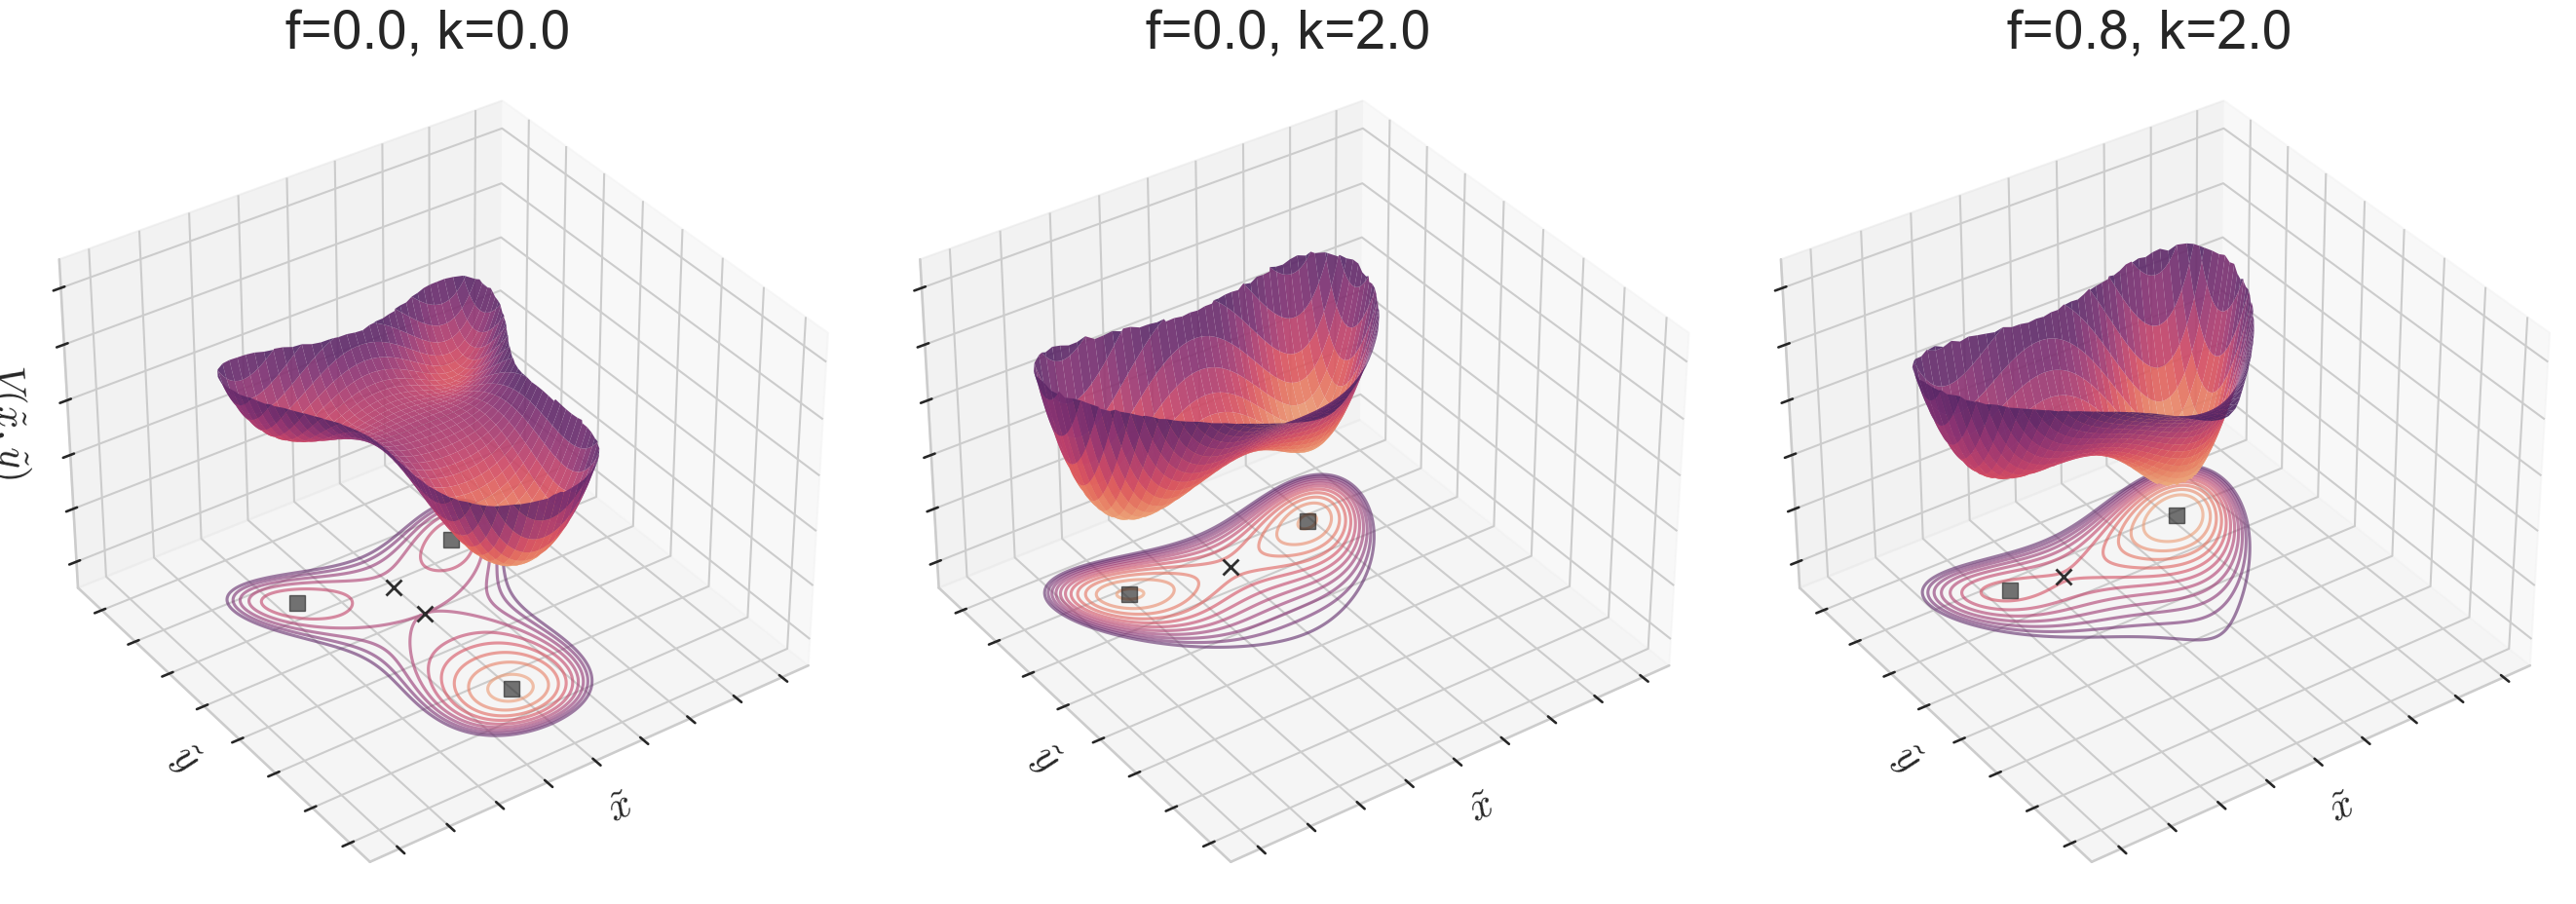

In [ ]:
def plot_het_flip_3d_subplots():
    cases = [(0,0), (0,2), (0.8,2)]
    fig = plt.figure(figsize=(30,10))
    for idx,(f,k) in enumerate(cases):
        nx=500
        params={'f':f,'k':k}
        x = np.linspace(-2, 2, nx)
        y = np.linspace(-1.6, 2, nx)
        X,Y=np.meshgrid(x,y)
        cap=0.7
        Z=het_flip_pot(X,Y,params); Z=np.clip(Z,-2.5,cap)
        ax=fig.add_subplot(1,3,idx+1,projection='3d')
        cmap_flare=sns.color_palette('flare',as_cmap=True)
        Z_plot=Z.copy(); Z_plot[Z_plot==cap]=np.nan
        surf=ax.plot_surface(X,Y,Z_plot,cmap=cmap_flare,alpha=0.9,edgecolor='none',antialiased=True)
        contour=ax.contour(X,Y,Z,levels=10,cmap=cmap_flare,offset=-3.5,alpha=0.6)
        ax.set_zlim(-3.5,2.5)
        ax.set_xlabel(r'$\tilde{x}$',fontsize=30); ax.set_ylabel(r'$\tilde{y}$',fontsize=30)
        if idx==0:
            ax.set_zlabel(r'$V(\tilde{x}, \tilde{y})$', fontsize=30, labelpad=6); ax.zaxis.label.set_clip_on(False)
        ax.set_xticklabels([]); ax.set_yticklabels([]); ax.set_zticklabels([])
        ax.set_title(f'f={f:.1f}, k={k:.1f}', fontsize=40)

        # Find and plot critical points & separatrices for each subplot (preserve limits)
        critical_points = []
        for x0 in np.linspace(-2, 2, 5):
            for y0 in np.linspace(-1.6, 2, 5):
                sol = fsolve(lambda pos: het_flip_grad(pos[0], pos[1], params), [x0, y0], full_output=True)
                if sol[2] == 1:
                    point = sol[0]
                    is_new = True
                    for existing_point in critical_points:
                        if np.linalg.norm(point - existing_point) < 0.1:
                            is_new = False
                            break
                    if is_new:
                        critical_points.append(point)

        attractors = []
        saddles = []
        for point in critical_points:
            x_pt, y_pt = point
            h = 1e-5
            d2V_dx2 = (het_flip_grad(x_pt + h, y_pt, params)[0] - het_flip_grad(x_pt - h, y_pt, params)[0]) / (2*h)
            d2V_dy2 = (het_flip_grad(x_pt, y_pt + h, params)[1] - het_flip_grad(x_pt, y_pt - h, params)[1]) / (2*h)
            if d2V_dx2 > 0 and d2V_dy2 > 0:
                attractors.append(point)
            else:
                saddles.append(point)

        for attractor in attractors:
            ax.plot(attractor[0], attractor[1], -3.5, 'ks', alpha=0.6, markersize=12)
        for saddle in saddles:
            ax.plot(saddle[0], saddle[1], -3.5, 'kx', alpha=0.9, markersize=12, markeredgewidth=2)

        ax.view_init(elev=35, azim=55)
        # project unstable manifolds onto the x-y plane at z=-3.5
        bounds = (x.min(), x.max(), y.min(), y.max())
        for saddle in saddles:
            for xs, ys in unstable_manifold_trajectories(saddle, het_flip_grad, params, bounds, eps=1e-3, t_max=60, n_steps=1200):
                ax.plot(xs, ys, -3.5 * np.ones_like(xs), color='k', linewidth=1.8, linestyle='--', alpha=0.9)
    fig.subplots_adjust(left=0.12, right=0.995, wspace=0.03, top=0.92, bottom=0.06)
    plt.show()

plot_het_flip_3d_subplots()

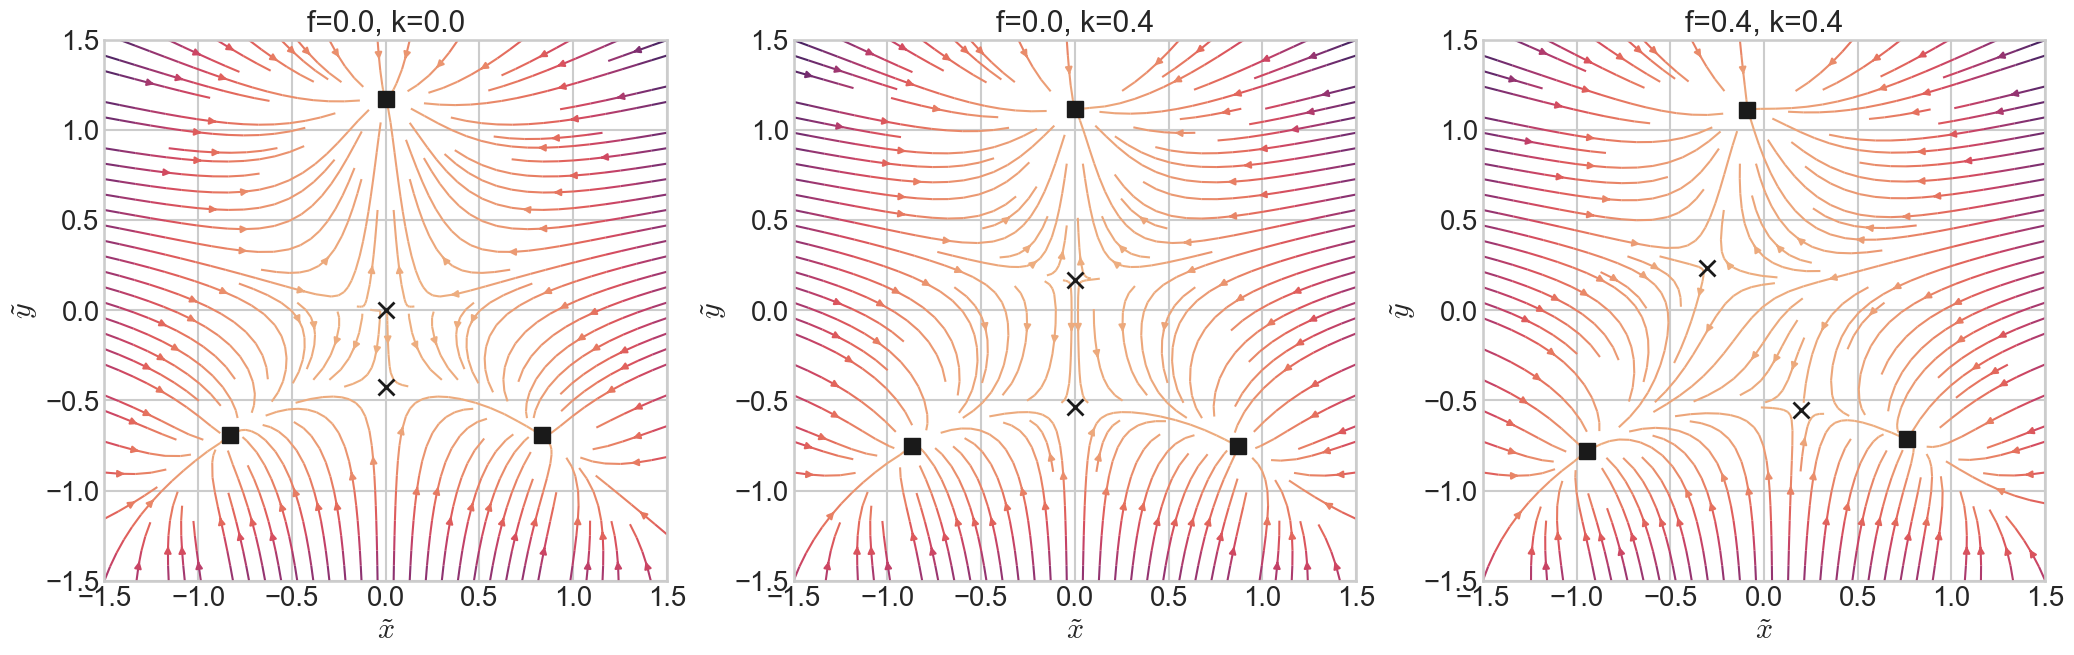

In [ ]:
def plot_het_flip_streams_3d_subplots():
    cases = [(0,0),(0,0.4),(0.4,0.4)]
    fig, axes = plt.subplots(1,3,figsize=(21,7))
    for idx,(f,k) in enumerate(cases):
        params={'f':f,'k':k}
        nx=1000
        x=np.linspace(-1.5,1.5,nx); y=np.linspace(-1.5,1.5,nx); X,Y=np.meshgrid(x,y)
        Z=het_flip_pot(X,Y,params); DX,DY=het_flip_grad(X,Y,params)
        speed=np.hypot(DX,DY)
        ax=axes[idx]
        cmap_flare=sns.color_palette('flare',as_cmap=True); norm=mpl.colors.Normalize(vmin=0,vmax=np.nanmax(speed))
        ax.streamplot(X,Y,-DX,-DY,color=speed,cmap=cmap_flare,norm=norm,density=1.2,linewidth=1.5,broken_streamlines=True)
        # ax.contour(X,Y,-DX,levels=[0],colors='gray',linewidths=2,linestyles='--')
        # ax.contour(X,Y,-DY,levels=[0],colors='gray',linewidths=2,linestyles='-')
        # compute critical points for this case and plot separatrices
        critical_points = []
        for x0 in np.linspace(-1.5, 1.5, 5):
            for y0 in np.linspace(-1.5, 1.5, 5):
                sol = fsolve(lambda pos: het_flip_grad(pos[0], pos[1], params), [x0, y0], full_output=True)
                if sol[2] == 1:
                    point = sol[0]
                    is_new = True
                    for existing_point in critical_points:
                        if np.linalg.norm(point - existing_point) < 0.1:
                            is_new = False
                            break
                    if is_new:
                        critical_points.append(point)

        # classify and plot attractors/saddles & separatrices
        attractors = []
        saddles = []
        for point in critical_points:
            x_pt, y_pt = point
            h = 1e-5
            d2V_dx2 = (het_flip_grad(x_pt + h, y_pt, params)[0] - het_flip_grad(x_pt - h, y_pt, params)[0]) / (2*h)
            d2V_dy2 = (het_flip_grad(x_pt, y_pt + h, params)[1] - het_flip_grad(x_pt, y_pt - h, params)[1]) / (2*h)
            if d2V_dx2 > 0 and d2V_dy2 > 0:
                attractors.append(point)
            else:
                saddles.append(point)

        # ax.contour(X, Y, -DX, levels=[0], colors='gray', linewidths=2, linestyles='--')
        # ax.contour(X, Y, -DY, levels=[0], colors='gray', linewidths=2, linestyles='-')

        for attractor in attractors:
            ax.plot(attractor[0], attractor[1], 'ks', markersize=12)
        for saddle in saddles:
            ax.plot(saddle[0], saddle[1], 'kx', markersize=12, markeredgewidth=2)
            # restore nullclines instead of separatrices
            ax.contour(X, Y, -DX, levels=[0], colors='gray', linewidths=2, linestyles='--')
            ax.contour(X, Y, -DY, levels=[0], colors='gray', linewidths=2, linestyles='-')
            # plot unstable manifolds
            bounds = (-1.5, 1.5, -1.5, 1.5)
            for xs, ys in unstable_manifold_trajectories(saddle, het_flip_grad, params, bounds, eps=1e-3, t_max=40, n_steps=800):
                ax.plot(xs, ys, color='k', linewidth=1.6, linestyle='--', alpha=0.9)

        ax.set_xlabel(r'$\tilde{x}$'); ax.set_ylabel(r'$\tilde{y}$'); ax.set_title(f'f={f:.1f}, k={k:.1f}')
        ax.set_xlim(-1.5,1.5); ax.set_ylim(-1.5,1.5)
    plt.tight_layout(); plt.show()

plot_het_flip_streams_3d_subplots()

In [202]:
def plot_double_cusp_streams_attractors_saddles(f, k):
    params = {'f': f, 'k': k}
    x = np.linspace(-1.5, 1.5, 300)
    y = np.linspace(-1.5, 1.5, 300)
    X, Y = np.meshgrid(x, y)

    Z = double_cusp_pot(X, Y, params)
    DX, DY = double_cusp_grad(X, Y, params)

    # Find critical points
    critical_points = []
    for x0 in np.linspace(-1.5, 1.5, 5):
        for y0 in np.linspace(-1.5, 1.5, 5):
            sol = fsolve(lambda pos: double_cusp_grad(pos[0], pos[1], params), [x0, y0], full_output=True)
            if sol[2] == 1:
                point = sol[0]
                is_new = True
                for existing_point in critical_points:
                    if np.linalg.norm(point - existing_point) < 0.1:
                        is_new = False
                        break
                if is_new:
                    critical_points.append(point)

    attractors = []
    saddles = []
    for point in critical_points:
        x_pt, y_pt = point
        h = 1e-5
        d2V_dx2 = (double_cusp_grad(x_pt + h, y_pt, params)[0] - double_cusp_grad(x_pt - h, y_pt, params)[0]) / (2*h)
        d2V_dy2 = (double_cusp_grad(x_pt, y_pt + h, params)[1] - double_cusp_grad(x_pt, y_pt - h, params)[1]) / (2*h)
        if d2V_dx2 > 0 and d2V_dy2 > 0:
            attractors.append(point)
        else:
            saddles.append(point)

    speed = np.hypot(DX, DY)
    fig, ax = plt.subplots(figsize=(8,8))
    cmap_flare = sns.color_palette('flare', as_cmap=True)
    norm = mpl.colors.Normalize(vmin=0, vmax=np.nanmax(speed))
    ax.streamplot(X, Y, -DX, -DY, color=speed, cmap=cmap_flare, norm=norm, density=1.2, linewidth=1.2, broken_streamlines=True)
    ax.contour(X, Y, -DX, levels=[0], colors='gray', linewidths=2, linestyles='--')
    ax.contour(X, Y, -DY, levels=[0], colors='gray', linewidths=2, linestyles='-')

    for attractor in attractors:
        ax.plot(attractor[0], attractor[1], 'ks', markersize=12)
    for saddle in saddles:
        ax.plot(saddle[0], saddle[1], 'kx', markersize=12, markeredgewidth=2)

    ax.set_xlabel(r'$\tilde{x}$')
    ax.set_ylabel(r'$\tilde{y}$')
    ax.set_xlim(-1.5,1.5)
    ax.set_ylim(-1.5,1.5)
    ax.set_aspect('equal')
    ax.set_title(f'Double Cusp Potential (f={f:.2f}, k={k:.2f})')
    cbar = plt.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap_flare), ax=ax, label='||dV/dm||')
    plt.tight_layout()
    plt.show()

interact(plot_double_cusp_streams_attractors_saddles,
         f=FloatSlider(min=-2, max=2, step=0.1, value=0),
         k=FloatSlider(min=-2, max=2, step=0.1, value=0))

interactive(children=(FloatSlider(value=0.0, description='f', max=2.0, min=-2.0), FloatSlider(value=0.0, descr…

<function __main__.plot_double_cusp_streams_attractors_saddles(f, k)>

In [ ]:
def plot_double_cusp_3d_interactive(f, k):
    params = {'f': f, 'k': k}
    nx = 500
    x = np.linspace(-1.5, 1.5, nx)
    y = np.linspace(-1.5, 1.5, nx)
    X, Y = np.meshgrid(x, y)
    cap = 0.7
    Z = double_cusp_pot(X, Y, params)
    Z = np.clip(Z, -1, cap)

    fig = plt.figure(figsize=(10,8))
    ax = fig.add_subplot(111, projection='3d')
    cmap_flare = sns.color_palette('flare', as_cmap=True)
    Z_plot = Z.copy(); Z_plot[Z_plot == cap] = np.nan
    surf = ax.plot_surface(X, Y, Z_plot, cmap=cmap_flare, alpha=0.9, edgecolor='none', antialiased=True)
    contour = ax.contour(X, Y, Z, levels=10, cmap=cmap_flare, offset=-2, alpha=0.6)
    ax.set_zlim(-2,2.5)
    ax.set_xlabel(r'$\tilde{x}$', fontsize=20); ax.set_ylabel(r'$\tilde{y}$', fontsize=20); ax.set_zlabel(r'$V(\tilde{x}, \tilde{y})$', fontsize=20)
    ax.set_xticklabels([]); ax.set_yticklabels([]); ax.set_zticklabels([])
    ax.set_title(f'Double Cusp Potential (f={f:.1f}, k={k:.1f})', fontsize=24)
    # Find and plot critical points & separatrices (preserve limits)
    critical_points = []
    for x0 in np.linspace(-1.5, 1.5, 5):
        for y0 in np.linspace(-1.5, 1.5, 5):
            sol = fsolve(lambda pos: double_cusp_grad(pos[0], pos[1], params), [x0, y0], full_output=True)
            if sol[2] == 1:
                point = sol[0]
                is_new = True
                for existing_point in critical_points:
                    if np.linalg.norm(point - existing_point) < 0.1:
                        is_new = False
                        break
                if is_new:
                    critical_points.append(point)

    attractors = []
    saddles = []
    for point in critical_points:
        x_pt, y_pt = point
        h = 1e-5
        d2V_dx2 = (double_cusp_grad(x_pt + h, y_pt, params)[0] - double_cusp_grad(x_pt - h, y_pt, params)[0]) / (2*h)
        d2V_dy2 = (double_cusp_grad(x_pt, y_pt + h, params)[1] - double_cusp_grad(x_pt, y_pt - h, params)[1]) / (2*h)
        if d2V_dx2 > 0 and d2V_dy2 > 0:
            attractors.append(point)
        else:
            saddles.append(point)

    for attractor in attractors:
        ax.plot(attractor[0], attractor[1], -2, 'ks', alpha=0.6, markersize=12)
    for saddle in saddles:
        ax.plot(saddle[0], saddle[1], -2, 'kx', alpha=0.9, markersize=12, markeredgewidth=2)
        Vs = double_cusp_pot(saddle[0], saddle[1], params)
        ax.contour(X, Y, Z, levels=[Vs], colors='k', linewidths=1.5, linestyles='--', offset=-2)
        # plot unstable manifolds projected onto x-y plane at offset z = -2
        bounds = (-1.5, 1.5, -1.5, 1.5)
        for xs, ys in unstable_manifold_trajectories(saddle, double_cusp_grad, params, bounds, eps=1e-3, t_max=50, n_steps=1000):
            ax.plot(xs, ys, -2*np.ones_like(xs), color='k', linewidth=2, linestyle='--', alpha=0.9)

    plt.show()

interact(plot_double_cusp_3d_interactive,
         f=FloatSlider(min=-2, max=2, step=0.1, value=0),
         k=FloatSlider(min=-2, max=2, step=0.1, value=0))

In [ ]:
def plot_double_cusp_3d_subplots():
    cases = [(0,0), (0,0.4), (0.4,0.4)]
    fig = plt.figure(figsize=(30,10))
    for idx,(f,k) in enumerate(cases):
        params={'f':f,'k':k}
        nx=500
        x=np.linspace(-1.5,1.5,nx); y=np.linspace(-1.5,1.5,nx); X,Y=np.meshgrid(x,y)
        cap=0.7
        Z=double_cusp_pot(X,Y,params); Z=np.clip(Z,-1,cap)
        ax=fig.add_subplot(1,3,idx+1,projection='3d')
        cmap_flare=sns.color_palette('flare',as_cmap=True)
        Z_plot=Z.copy(); Z_plot[Z_plot==cap]=np.nan
        surf=ax.plot_surface(X,Y,Z_plot,cmap=cmap_flare,alpha=0.9,edgecolor='none',antialiased=True)
        contour=ax.contour(X,Y,Z,levels=10,cmap=cmap_flare,offset=-2,alpha=0.6)
        ax.set_zlim(-2,2.5)
        ax.set_xlabel(r'$\tilde{x}$',fontsize=30); ax.set_ylabel(r'$\tilde{y}$',fontsize=30)
        if idx==0:
            ax.set_zlabel(r'$V(\tilde{x}, \tilde{y})$', fontsize=30, labelpad=6); ax.zaxis.label.set_clip_on(False)
        ax.set_xticklabels([]); ax.set_yticklabels([]); ax.set_zticklabels([])
        ax.set_title(f'f={f:.1f}, k={k:.1f}', fontsize=40)
        ax.view_init(elev=35, azim=55)
        # Find and mark critical points for this subplot and draw separatrices
        critical_points = []
        for x0 in np.linspace(-1.5, 1.5, 5):
            for y0 in np.linspace(-1.5, 1.5, 5):
                sol = fsolve(lambda pos: double_cusp_grad(pos[0], pos[1], params), [x0, y0], full_output=True)
                if sol[2] == 1:
                    point = sol[0]
                    is_new = True
                    for existing_point in critical_points:
                        if np.linalg.norm(point - existing_point) < 0.1:
                            is_new = False
                            break
                    if is_new:
                        critical_points.append(point)

        attractors = []
        saddles = []
        for point in critical_points:
            x_pt, y_pt = point
            h = 1e-5
            d2V_dx2 = (double_cusp_grad(x_pt + h, y_pt, params)[0] - double_cusp_grad(x_pt - h, y_pt, params)[0]) / (2*h)
            d2V_dy2 = (double_cusp_grad(x_pt, y_pt + h, params)[1] - double_cusp_grad(x_pt, y_pt - h, params)[1]) / (2*h)
            if d2V_dx2 > 0 and d2V_dy2 > 0:
                attractors.append(point)
            else:
                saddles.append(point)

        for attractor in attractors:
            ax.plot(attractor[0], attractor[1], -2, 'ks', alpha=0.6, markersize=12)
        for saddle in saddles:
            ax.plot(saddle[0], saddle[1], -2, 'kx', alpha=0.9, markersize=12, markeredgewidth=2)
            # restore nullclines on the x-y plane at offset -2
            ax.contour(X, Y, -DX, levels=[0], colors='gray', linewidths=2, linestyles='--', offset=-2)
            ax.contour(X, Y, -DY, levels=[0], colors='gray', linewidths=2, linestyles='-', offset=-2)
        # project unstable manifolds onto the x-y plane at z=-2
        bounds = (x.min(), x.max(), y.min(), y.max())
        for saddle in saddles:
            for xs, ys in unstable_manifold_trajectories(saddle, double_cusp_grad, params, bounds, eps=1e-3, t_max=50, n_steps=1000):
                ax.plot(xs, ys, -2 * np.ones_like(xs), color='k', linewidth=1.8, linestyle='--', alpha=0.9)
    fig.subplots_adjust(left=0.12, right=0.995, wspace=0.03, top=0.92, bottom=0.06)
    plt.show()

plot_double_cusp_3d_subplots()

In [ ]:
def plot_double_cusp_streams_3d_subplots():
    cases = [(0,0),(0,0.4),(0.4,0.4)]
    fig, axes = plt.subplots(1,3,figsize=(21,7))
    for idx,(f,k) in enumerate(cases):
        params={'f':f,'k':k}
        nx=1000
        x=np.linspace(-1.5,1.5,nx); y=np.linspace(-1.5,1.5,nx); X,Y=np.meshgrid(x,y)
        Z=double_cusp_pot(X,Y,params); DX,DY=double_cusp_grad(X,Y,params)
        speed=np.hypot(DX,DY)
        ax=axes[idx]
        cmap_flare=sns.color_palette('flare',as_cmap=True); norm=mpl.colors.Normalize(vmin=0,vmax=np.nanmax(speed))
        ax.streamplot(X,Y,-DX,-DY,color=speed,cmap=cmap_flare,norm=norm,density=1.2,linewidth=1.5,broken_streamlines=True)
        # ax.contour(X,Y,-DX,levels=[0],colors='gray',linewidths=2,linestyles='--')
        # ax.contour(X,Y,-DY,levels=[0],colors='gray',linewidths=2,linestyles='-')
        critical_points = []
        for x0 in np.linspace(-1.5, 1.5, 5):
            for y0 in np.linspace(-1.5, 1.5, 5):
                sol = fsolve(lambda pos: double_cusp_grad(pos[0], pos[1], params), [x0, y0], full_output=True)
                if sol[2] == 1:
                    point = sol[0]
                    is_new = True
                    for existing_point in critical_points:
                        if np.linalg.norm(point - existing_point) < 0.1:
                            is_new = False
                            break
                    if is_new:
                        critical_points.append(point)

        attractors = []
        saddles = []
        for point in critical_points:
            x_pt, y_pt = point
            h = 1e-5
            d2V_dx2 = (double_cusp_grad(x_pt + h, y_pt, params)[0] - double_cusp_grad(x_pt - h, y_pt, params)[0]) / (2*h)
            d2V_dy2 = (double_cusp_grad(x_pt, y_pt + h, params)[1] - double_cusp_grad(x_pt, y_pt - h, params)[1]) / (2*h)
            if d2V_dx2 > 0 and d2V_dy2 > 0:
                attractors.append(point)
            else:
                saddles.append(point)

        for attractor in attractors:
            ax.plot(attractor[0], attractor[1], 'ks', markersize=12, alpha=0.6)
        for saddle in saddles:
            ax.plot(saddle[0], saddle[1], 'kx', markersize=12, markeredgewidth=2, alpha=0.9)
            # restore nullclines instead of separatrices
            ax.contour(X, Y, -DX, levels=[0], colors='gray', linewidths=2, linestyles='--')
            ax.contour(X, Y, -DY, levels=[0], colors='gray', linewidths=2, linestyles='-')
            # unstable manifolds
            bounds = (-1.5, 1.5, -1.5, 1.5)
            for xs, ys in unstable_manifold_trajectories(saddle, double_cusp_grad, params, bounds, eps=1e-3, t_max=40, n_steps=800):
                ax.plot(xs, ys, color='k', linewidth=1.6, linestyle='--', alpha=0.9)
        ax.set_xlabel(r'$\\tilde{x}$'); ax.set_ylabel(r'$\\tilde{y}$'); ax.set_title(f'f={f:.1f}, k={k:.1f}')
        ax.set_xlim(-1.5,1.5); ax.set_ylim(-1.5,1.5)
    plt.tight_layout(); plt.show()

plot_double_cusp_streams_3d_subplots()